In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/cleaned/retail_cleaned.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(df.shape)

(407664, 12)


In [2]:
# Set reference date as one day after last transaction
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Calculate RFM
rfm = df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

print(rfm.head())
print(rfm.shape)

   Customer ID  Recency  Frequency  Monetary
0      12346.0      165         11    372.86
1      12347.0        3          2   1323.32
2      12348.0       74          1    222.16
3      12349.0       43          3   2671.14
4      12351.0       11          1    300.93
(4312, 4)


In [3]:
# Score each metric 1-5
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=5, labels=[1,2,3,4,5])

# Combine into single RFM score
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print(rfm.head(10))

   Customer ID  Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score
0      12346.0      165         11    372.86       2       5       2       252
1      12347.0        3          2   1323.32       5       2       4       524
2      12348.0       74          1    222.16       2       1       1       211
3      12349.0       43          3   2671.14       3       3       5       335
4      12351.0       11          1    300.93       5       1       2       512
5      12352.0       11          2    343.80       5       2       2       522
6      12353.0       44          1    317.76       3       1       2       312
7      12355.0      203          1    488.21       1       1       2       112
8      12356.0       16          3   3562.25       4       3       5       435
9      12357.0       24          2  12079.99       4       2       5       425


In [4]:
def segment_customer(row):
    score = row['RFM_Score']
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At-Risk'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    else:
        return 'Potential Loyalists'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

print(rfm['Segment'].value_counts())

Segment
Loyal Customers        973
Champions              926
Lost                   833
Potential Loyalists    702
At-Risk                511
New Customers          367
Name: count, dtype: int64


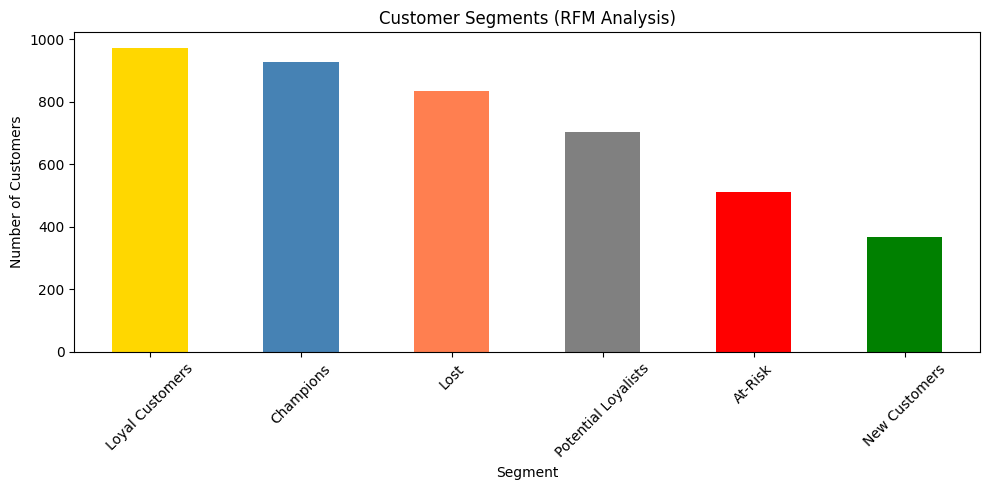

In [5]:
plt.figure(figsize=(10, 5))
colors = ['gold', 'steelblue', 'coral', 'gray', 'red', 'green']
rfm['Segment'].value_counts().plot(kind='bar', color=colors)
plt.title('Customer Segments (RFM Analysis)')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\moham\AppData\Local\Temp\ipykernel_20588\468102494.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_revenue, x='Monetary', y='Segment', palette='RdYlGn')


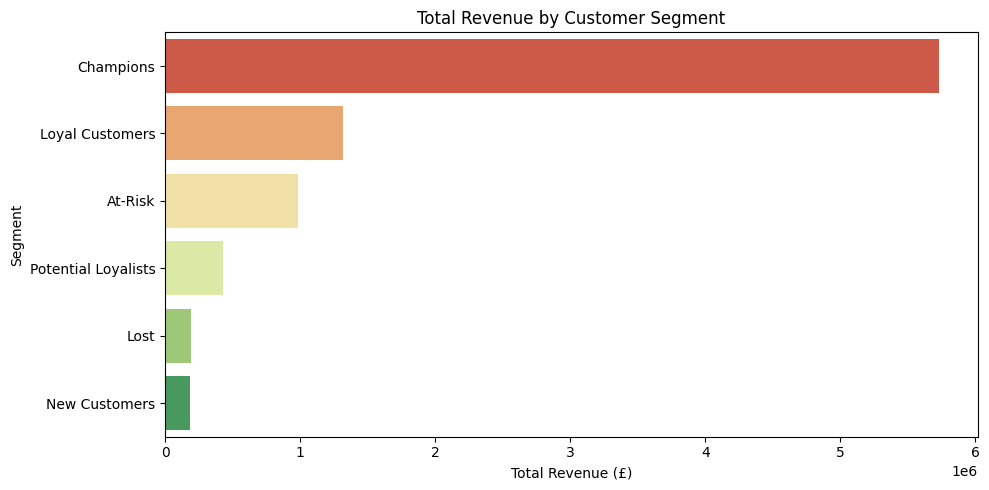

In [6]:
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().reset_index()
segment_revenue = segment_revenue.sort_values('Monetary', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=segment_revenue, x='Monetary', y='Segment', palette='RdYlGn')
plt.title('Total Revenue by Customer Segment')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Segment')
plt.tight_layout()
plt.show()

C:\Users\moham\AppData\Local\Temp\ipykernel_828\822387740.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_customers, x='Revenue', y='Customer ID', palette='Oranges_r')


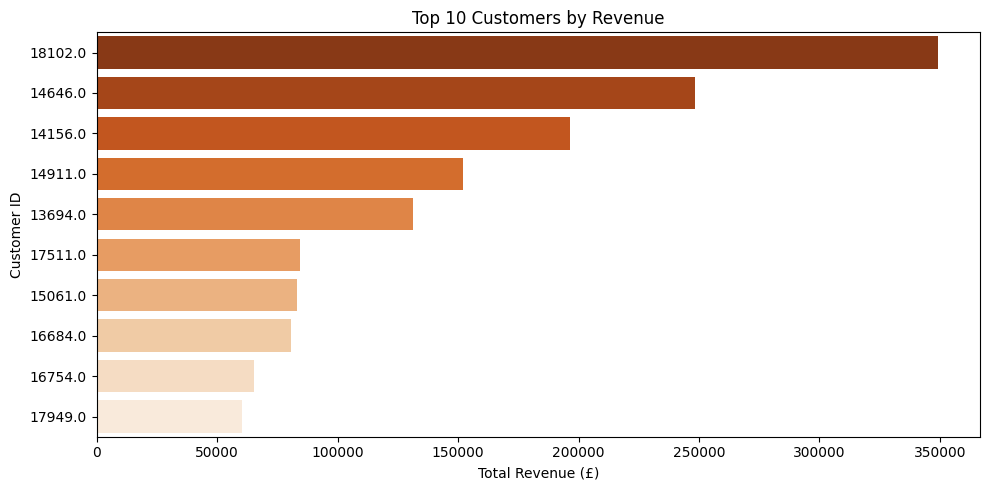

In [ ]:
top_customers = df.groupby('Customer ID')['Revenue'].sum().reset_index()
top_customers = top_customers.sort_values('Revenue', ascending=False).head(10)
top_customers['Customer ID'] = top_customers['Customer ID'].astype(str)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_customers, x='Revenue', y='Customer ID', palette='Oranges_r')
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Total Revenue (£)')
plt.tight_layout()
plt.show()

In [7]:
rfm.to_excel('../excel/rfm_segments.xlsx', index=False)
print("Saved successfully")

Saved successfully
